# Acqua Alta Dataset


Import libraries


In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from custom_lstm.utils import generate_regime_data
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from hurst import compute_Hc

In [2]:
OUTPUT_FILE = "../../data/preprocessed/SyntheticSine.csv"
TARGET_COL = "Water Height;(m)"

In [3]:
# --- HYPERPARAMETERS ---
TOTAL_SAMPLES = 3300  # Total pool of data
TRAIN_RATIO = 0.8
SAMPLING_RATE = 3000  # 100 data points per second (Hz)

# --- GENERATION ---
# Calculate sizes based on Ratio
n_train = int(TOTAL_SAMPLES * TRAIN_RATIO)
n_test = TOTAL_SAMPLES - n_train

print(f"Generating {n_train} Train samples and {n_test} Test samples...")

# Generate using the SAME sampling_rate
time_series_train, _ = generate_regime_data(n_points=n_train, sampling_rate=SAMPLING_RATE)
time_series_test, _ = generate_regime_data(n_points=n_test, sampling_rate=SAMPLING_RATE)

print(f"Train Shape: {time_series_train.shape}")
print(f"Test Shape:  {time_series_test.shape}")

Generating 2640 Train samples and 660 Test samples...
Train Shape: torch.Size([2640, 1])
Test Shape:  torch.Size([660, 1])


In [4]:
time_series = pd.DataFrame(np.concatenate((time_series_train, time_series_test)), columns=["time_series"])

In [5]:
time_series.to_csv(OUTPUT_FILE, index=False)

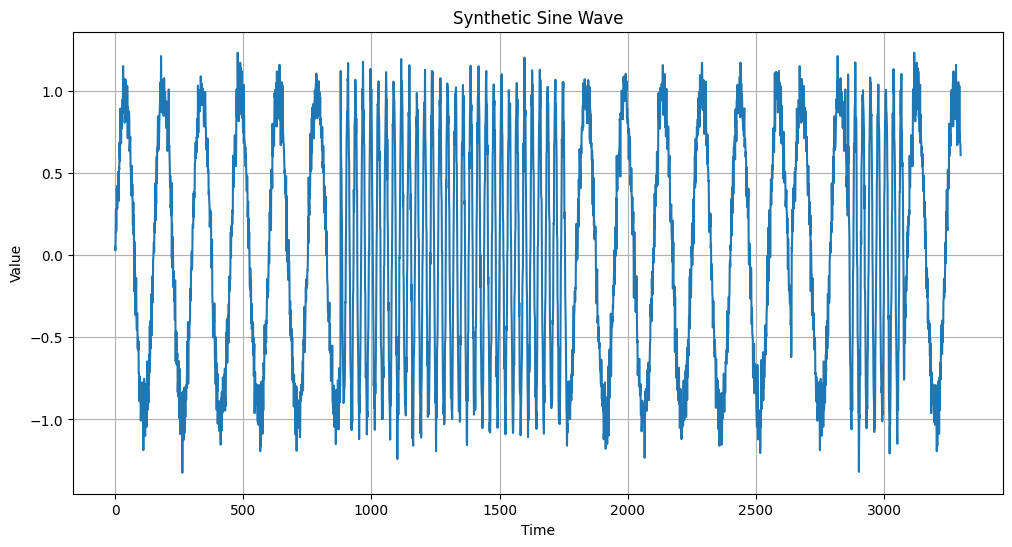

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(time_series, label="Time Series")
plt.title("Synthetic Sine Wave")
plt.xlabel("Time")
plt.ylabel("Value")
plt.grid(True)

### ACF

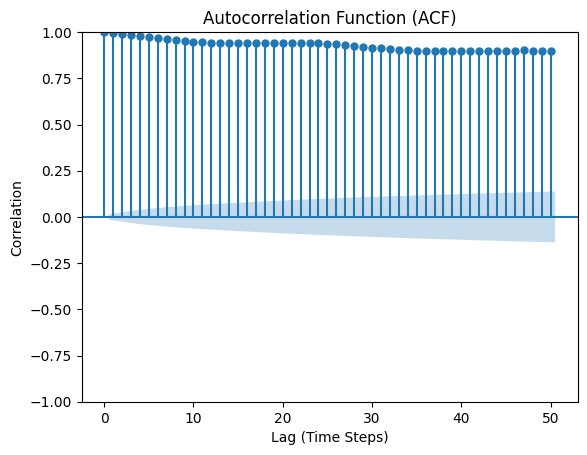

In [ ]:
plot_acf(time_series, lags=50, alpha=0.05)
plt.title("Autocorrelation Function (ACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

### PACF

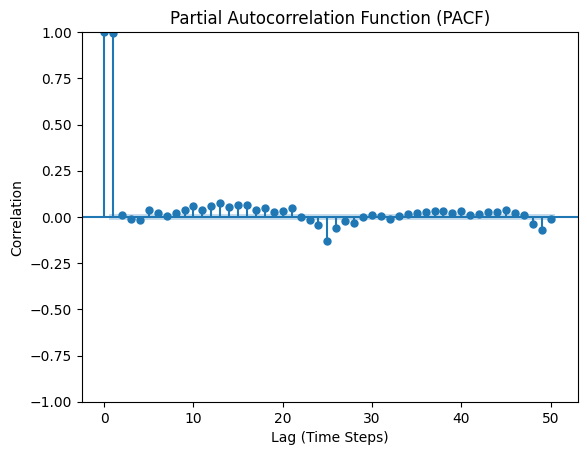

In [ ]:
plot_pacf(time_series, lags=50)
plt.title("Partial Autocorrelation Function (PACF)")
plt.xlabel("Lag (Time Steps)")
plt.ylabel("Correlation")
plt.show()

## Hurst Exponent


Hurst Exponent (H): 0.8945


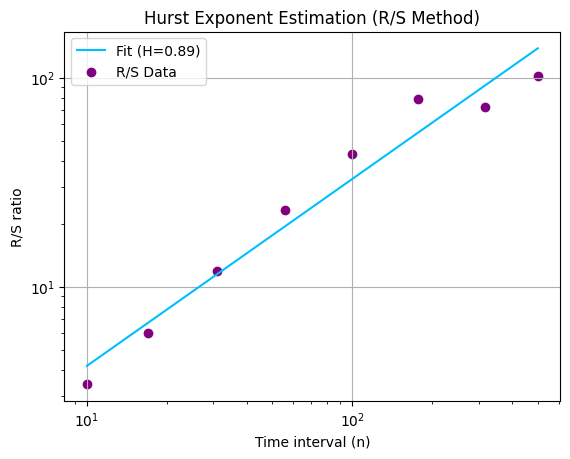

In [8]:
H, c, data = compute_Hc(time_series[000:500], kind="change", simplified=False)

print(f"Hurst Exponent (H): {H:.4f}")
f, ax = plt.subplots()
ax.plot(data[0], c * data[0] ** H, color="deepskyblue", label=f"Fit (H={H:.2f})")
ax.scatter(data[0], data[1], color="purple", label="R/S Data")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Time interval (n)")
ax.set_ylabel("R/S ratio")
ax.legend()
plt.title("Hurst Exponent Estimation (R/S Method)")
plt.grid(True)
plt.show()